## 蚁群算法  

### 蚁群算法的起源  
双桥实验：通过遗留在来往路径上的信息素的挥发性物质来进行通信和协调  
自然蚂蚁觅食是一种群体性行为，并非单只蚂蚁自行寻找食物，蚂蚁在寻找食物来源时，会在其经过的路径上释放一种信息素，并能感知其他蚂蚁释放的信息素。
起源：意大利学者M.Dorigo提出《nature》中有综述

### 原理分析  
人工蚂蚁与真实蚂蚁的异同：  
相同点：  
    两个群体中都存在个体相互交流的通信机制  
    都要完成寻找最短路径的任务  
    都采用当前信息进行路径选择的随机选择策略  
不同点：  
    人工蚂蚁都有记忆  
    人工蚂蚁选择路径不是完全盲目的，会受问题空间特征的启发  
    人工蚂蚁生活在离散空间；真实蚂蚁生活在连续时间的环境中  

## 蚁群算法的模型与实现  
解决TSP问题：  
假设每只蚂蚁都具有如下特征的智能体：
1. 每次周游，在路径上都会留下信息素
2. 蚂蚁选择城市的概率与城市距离之间的距离和当前连接支路上所包含的信息素余量相关
3. 所有城市只能经历过一次
解决TSP问题：  
1. 在算法初始时将蚂蚁群随机的分布到不同城市中  
2. 根据距离和信息素水平，求出蚂蚁去往不同城市的概率，依照这个概率得到结果  
3. 当蚂蚁完成一次周游后，各路径上的信息素将进行更新  

### 改进  
Dorigo提出的不同模型  
1. 蚁周模型  
2. 蚁量模型  
3. 蚁密模型  
alpaha，beta对算法性能的影响：  
停滞现象：所有蚂蚁都选择相同的路径，原因在于这条路径上的信息素远大于其他的  
蚂蚁数量与城市数量的关系：差不多时，蚁周模型有较好的结果  

优点：鲁棒性，分布式计算，易于与其他方法结合  
缺点：计算量大，搜索时间长，容易出现停滞现象，基本蚁群算法本质上是离散的，不适用于连续优化分体  

## 蚁群算法解决TSP问题的基本原理
设整个蚂蚁群体中蚂蚁的数量为 $m$ ，城市的数量为 $n$ ，城市 $i$ 与城市 $d$ 之间的距离为 $d_{ij}$ ， $t$ 时刻城市 $i$ 与城市 $d$ 连接路径上的信息素浓度为 $i$ 与城市 $tau_{ij}(t)$ 。初始时刻，各个城市间连接路径上的信息素浓度相同，设为 $tau_{ij}(0) = tau_0$ 。  
蚂蚁 $k$ 根据各个城市间连接路径上的信息素浓度决定下一个访问的城市。设 $P^k_{ij}(t)$ 表示 $t$ 时刻蚂蚁 $k$ 从城市 $i$ 转移到城市 $j$ 的概率，计算公式如下：  
$$
P_{ij}^k(t) = 
\begin{cases}
\dfrac{[\tau_{ij}(t)]^\alpha \cdot [\eta_{ij}]^\beta}
     {\sum\limits_{l \in \mathcal{N}_i^k} [\tau_{il}(t)]^\alpha \cdot [\eta_{il}]^\beta}, & 
     \text{if } j \in \mathcal{N}_i^k \\
0, & \text{otherwise}
\end{cases}
$$  
其中， $\eta_{ij}$ 为启发函数， $\eta_{ij} = 1/d_{ij}$ ，表示蚂蚁从城市 $i$ 转移到城市 $j$ 的期望程度

然后介绍当所有蚂蚁完成一次循环后，各城市之间的路径上的信息素浓度需要进行更新  
$$
\tau_{ij}(t+1) = (1-\rho) \cdot \tau_{ij}(t) + \sum_{k=1}^{m} \Delta \tau_{ij}^k
$$
其中 $\Delta \tau_{ij}^k$ 是第 $k$ 只蚂蚁在城市 $i$ 和城市 $j$ 之间释放的信息素， $\rho$ 为信息素的蒸发系数。  

针对 $\Delta \tau_{ij}^k$ 的计算，M.Dorigo等人给出了三种不同的模型：蚁周模型  蚁量模型  蚁密模型   
蚁周模型： $\Delta \tau_{ij}^k = Q/L_k$ 其中 $Q$ 为恒定值，表示蚂蚁环游一圈释放的信息素总量， $L_k$ 表示第 $k$ 只蚂蚁经过的路径长度  
蚁量模型： $\Delta \tau_{ij}^k = Q/d_{ij}$  
蚁密模型： $\Delta \tau_{ij}^k = Q$  
通常使用蚁周模型


通常的步骤如下：  
1. 初始化参数：蚁群规模 $m$ ，信息素系数 $\alpha$ ，距离系数 $\beta$ ，挥发系数 $\rho$ ，信息素释放总量 $Q$   
2. 构造解空间：将各个蚂蚁随机地置于不同出发点，对每个蚂蚁计算其下一个待访问的城市，直到所有蚂蚁访问完所有的城市  
3. 更新信息素  
4. 判断是否终止  

问题描述：  
随机设定31个城市的位置，得出最近的周游距离。  
思路：  
首先随机生成31个城市在二维平面上的位置，然后计算各自的距离。  
然后初始化参数，迭代寻找最佳路径。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 创建城市位置
# 输入：城市数量size，坐标范围low_range到high_range
# 输出：城市坐标数组cities，形状为(size, 2)
def create_cities(size, low_range, high_range):
    cities = np.zeros((0, 2))
    i,j = 0,0
    while i < size:
        x = np.random.randint(low_range, high_range)
        y = np.random.randint(low_range, high_range)
        if not np.any(np.all(cities == [x, y], axis=1)):
            cities = np.vstack([cities, [x, y]])
            i += 1
        else:
            continue
    return cities

# 计算城市间距离矩阵
# 输入：城市坐标数组cities，形状为(size, 2)
# 输出：距离矩阵distance_matrix，形状为(size, size)
def caculate_distance(cities):
    size = cities.shape[0]
    distance_matrix = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            if i != j:
                distance = np.linalg.norm(cities[i] - cities[j])
                distance_matrix[i][j] = distance
            else:
                distance_matrix[i][j] = 1e-4
    return distance_matrix

# 可视化城市位置
# 输入：城市坐标数组cities，形状为(size, 2)
def plot_cities(cities):
    plt.figure(figsize=(8, 8))
    plt.scatter(cities[:, 0], cities[:, 1], c='blue', marker='o')
    for idx, (x, y) in enumerate(cities):
        plt.text(x, y, str(idx), fontsize=12, ha='right')
    plt.title('City Locations')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.show()

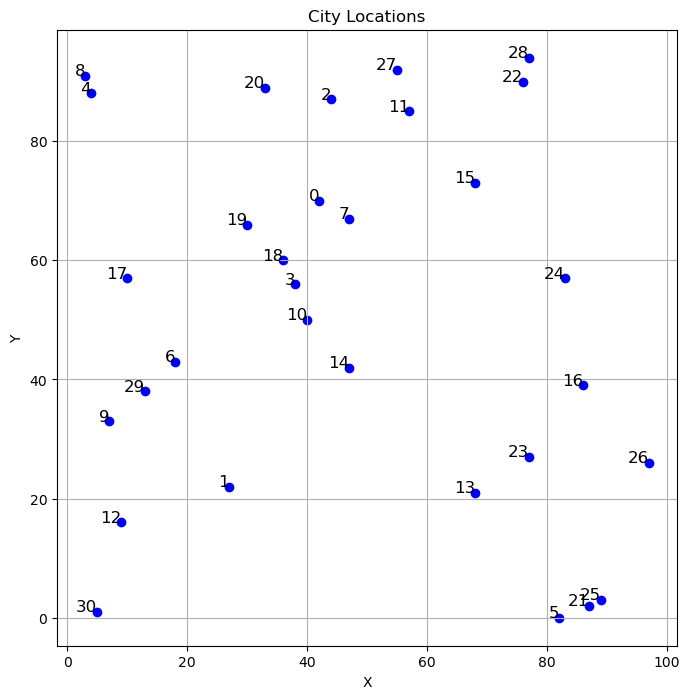

In [25]:
# 初始化参数
size = 31
ant = 50
low_range = 0
high_range = 100
cities = create_cities(size, low_range, high_range)
alpha = 1.0     # 信息素重要程度系数
beta = 5.0      # 启发函数重要程度系数
rho = 0.1       # 信息素挥发系数
Q = 1           # 信息素增量
eta = 1/caculate_distance(cities)
tau = np.ones((size, size))
route_table = np.zeros((0, size), dtype=int)        #建立周游表
iter = 1
max_iter = 100
best_route = np.zeros((max_iter, size), dtype=int)  # 记录每次迭代的最优路径
best_distance = np.zeros(max_iter)
ave_distance = np.zeros(max_iter)
distance_matrix = caculate_distance(cities)
plot_cities(cities)


In [26]:
for i_iter in range(max_iter):
    # 随机生成蚂蚁的起点城市
    start_city = np.random.randint(low=1, high=31, size=(ant, 1))

    # 生成周游表
    for i in range(ant):
        taboo_list = start_city[i].tolist()
        for j in range(size - 1):
            # 选择下一个城市
            current_city = taboo_list[-1]
            prob = np.zeros((1, size))
            for k in range(size):
                if k not in taboo_list:
                    prob[0][k] = (tau[current_city][k] ** alpha) * (eta[current_city][k] ** beta)
                else:
                    prob[0][k] = 0
            prob = prob / np.sum(prob)
            next_city = np.random.choice(range(size), p=prob.ravel())
            taboo_list.append(next_city)
        route_table = np.vstack([route_table, taboo_list])
            
    # 计算每只蚂蚁的路径长度
    distance_list = np.zeros((ant, 1))
    for i in range(ant):
        route = route_table[i]
        distance = 0
        for j in range(size - 1):
            distance += distance_matrix[route[j]][route[j + 1]]
        distance += distance_matrix[route[-1]][route[0]]
        distance_list[i] = distance

    # 更新信息素
    delta_tau = np.zeros((size, size))
    for i in range(ant):
        route = route_table[i]
        distance = distance_list[i][0]
        for j in range(size - 1):
            delta_tau[route[j]][route[j + 1]] += Q / distance
        delta_tau[route[-1]][route[0]] += Q / distance
    tau = (1 - rho) * tau + delta_tau

    # 记录当前迭代的最优路径和平均路径长度
    min_distance = np.min(distance_list)
    ave_distance[i_iter] = np.mean(distance_list)
    best_distance[i_iter] = min_distance
    best_route[i_iter] = route_table[np.argmin(distance_list)]
    route_table = np.zeros((0, size), dtype=int)  # 重置周

print(best_distance)


[537.65206712 528.08135293 552.61768589 535.7661837  585.61632784
 566.83388005 553.91638987 573.54445542 538.74422659 539.15220949
 523.9273584  565.08803962 533.34067153 574.0795394  541.78363725
 515.21245983 539.27380527 540.29800419 534.92168805 559.63272927
 544.31957771 539.3499188  542.95386548 488.25447    533.87573953
 527.40916669 544.28646397 530.00459517 536.30274752 520.53368087
 505.06861529 507.48732893 526.60812856 533.63192689 512.62995457
 522.09011508 515.16654329 532.62774489 505.75170396 527.18738155
 521.48889484 532.56094224 499.14237798 516.82400241 512.20106512
 517.48010129 517.55309796 538.19688896 486.66332408 517.48738476
 510.57832264 511.7501955  507.87247017 486.66332408 509.90064011
 513.64291035 517.48738476 498.15319583 503.53124959 508.68302237
 499.14237798 487.89223438 499.63281194 515.18666829 502.35678787
 505.86891344 499.56979884 519.57583137 501.23082458 500.00191428
 505.77483924 505.6196962  505.46459693 486.16602339 516.8837438
 488.25447 

In [27]:
print(best_route.shape)

(100, 31)


In [28]:
def plot_best_route(cities, best_route, title="TSP Optimal Route"):
    """
    绘制最优TSP路径
    
    参数:
    cities: 城市坐标数组，形状为(n, 2)
    best_route: 最优路径索引数组（如[0, 3, 1, 2, 0]或[0, 3, 1, 2]）
    title: 图表标题
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    plt.figure(figsize=(10, 8))
    
    # 确保路径是闭环
    if best_route[0] != best_route[-1]:
        route = np.append(best_route, best_route[0])
    else:
        route = best_route
    
    # 提取坐标
    route_coords = cities[route]
    
    # 绘制路径线
    plt.plot(route_coords[:, 0], route_coords[:, 1], 'b-', linewidth=2, alpha=0.7, zorder=3)
    
    # 绘制城市点
    plt.scatter(cities[:, 0], cities[:, 1], c='red', s=100, 
                edgecolors='black', linewidth=2, zorder=5)
    
    # 标记起点/终点
    plt.scatter(route_coords[0, 0], route_coords[0, 1], 
                c='green', s=200, marker='o', edgecolors='black', 
                linewidth=2, zorder=6, label='Start/End')
    
    # 显示城市编号
    for i, (x, y) in enumerate(cities):
        plt.text(x, y + 0.5, str(i), fontsize=12, ha='center', 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    
    # 计算总距离
    total_distance = 0
    for i in range(len(route) - 1):
        city_a = cities[route[i]]
        city_b = cities[route[i + 1]]
        total_distance += np.linalg.norm(city_a - city_b)
    
    plt.title(f"{title}\nTotal Distance: {total_distance:.2f}", fontsize=14, fontweight='bold')
    plt.xlabel("X Coordinate", fontsize=12)
    plt.ylabel("Y Coordinate", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.axis('equal')
    plt.tight_layout()
    
    return plt

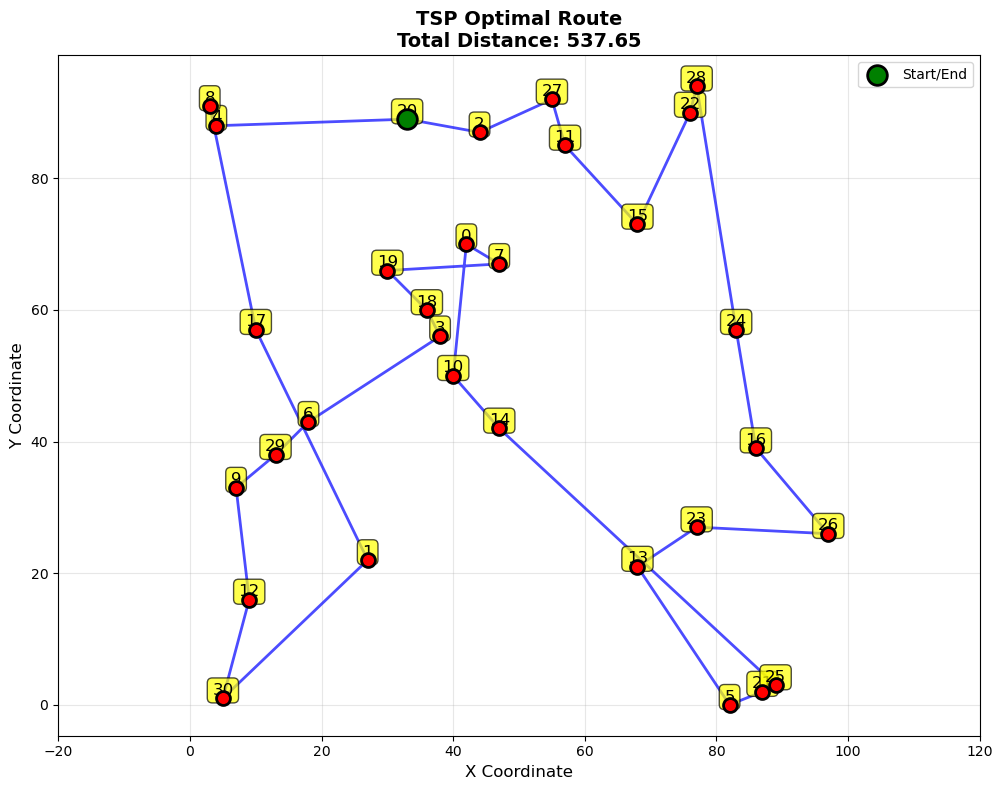

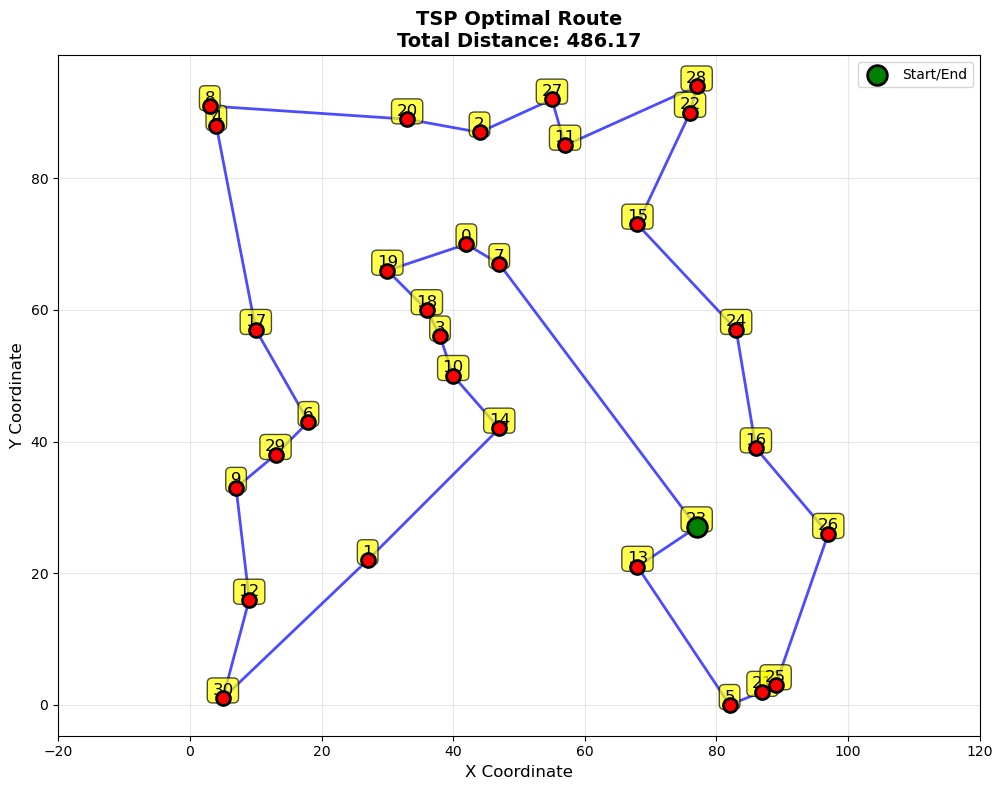

In [30]:
best_route_final = best_route[np.argmin(best_distance)]
best_route_1 = best_route[0]
plot_best_route(cities, best_route_1)
plt.show()
plot_best_route(cities, best_route_final)
plt.show()